<a href="https://colab.research.google.com/github/latidore/Genesis/blob/main/oblique_projection_to_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

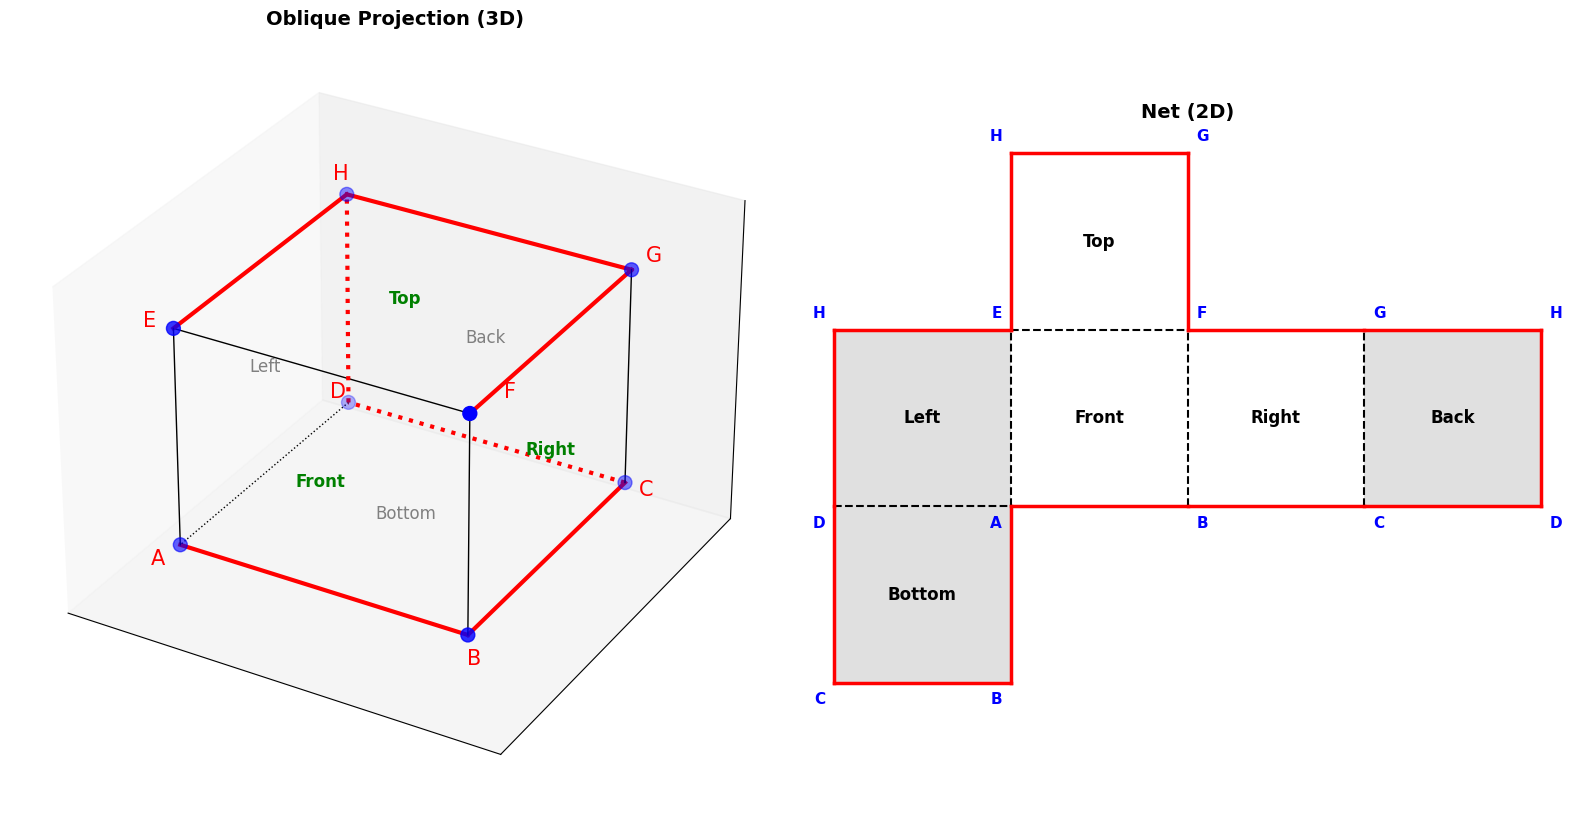

In [27]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as patches
import numpy as np

def draw_combined_cube_and_net():
    # 전체 그림 크기 설정 (가로를 넓게)
    fig = plt.figure(figsize=(16, 8))

    # ==========================================
    # 1. 왼쪽: 겨냥도 (3D Cube) - subplot(1, 2, 1)
    # ==========================================
    ax1 = fig.add_subplot(121, projection='3d')

    # 큐브의 꼭지점 정의 (중심이 원점, 변의 길이 2)
    vertices = np.array([
        [-1, -1, -1], # A (0)
        [ 1, -1, -1], # B (1)
        [ 1,  1, -1], # C (2)
        [-1,  1, -1], # D (3)
        [-1, -1,  1], # E (4)
        [ 1, -1,  1], # F (5)
        [ 1,  1,  1], # G (6)
        [-1,  1,  1]  # H (7)
    ])

    # 모서리 연결 정의
    edges = [
        (0, 1), (1, 2), (2, 3), (3, 0), # 밑면
        (4, 5), (5, 6), (6, 7), (7, 4), # 윗면
        (0, 4), (1, 5), (2, 6), (3, 7)  # 기둥
    ]

    # 점선으로 표시할 숨겨진 모서리
    hidden_edges_indices = [(7, 3), (2, 3), (3, 0)]

    # 빨간색 굵은 실선으로 강조할 모서리
    highlight_edges = [
        (4, 7), (7, 6), (6, 5), (7, 3), (3, 2), (0, 1), (1, 2)
    ]

    vertex_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

    # 꼭지점 그리기
    ax1.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2], color='blue', s=100)

    # 모서리 그리기
    for i, j in edges:
        is_hidden = (i, j) in hidden_edges_indices or (j, i) in hidden_edges_indices
        linestyle = ':' if is_hidden else '-'

        is_highlighted = (i, j) in highlight_edges or (j, i) in highlight_edges
        edge_color = 'red' if is_highlighted else 'black'
        linewidth = 3 if is_highlighted else 1

        ax1.plot(*zip(vertices[i], vertices[j]), color=edge_color, linestyle=linestyle, linewidth=linewidth)

    # 꼭지점 라벨 표시 (위치 미세 조정 포함)
    for i, (x, y, z) in enumerate(vertices):
        x_offset, y_offset, z_offset = x * 1.1, y * 1.1, z * 1.1
        if i == 3: # D
            x_offset, y_offset = x * 1.2, y * 1.2
        elif i == 5: # F
            x_offset, y_offset, z_offset = x * 1.2, y * 0.9, z * 1.2

        ax1.text(x_offset, y_offset, z_offset, vertex_labels[i], color='red', fontsize=15, ha='center', va='center')

    # 면 라벨 데이터
    faces_data = [
        {'label': 'Front',  'vertices': [0, 1, 5, 4]},
        {'label': 'Back',   'vertices': [3, 2, 6, 7]},
        {'label': 'Top',    'vertices': [4, 5, 6, 7]},
        {'label': 'Bottom', 'vertices': [0, 1, 2, 3]},
        {'label': 'Left',   'vertices': [0, 4, 7, 3]},
        {'label': 'Right',  'vertices': [1, 5, 6, 2]}
    ]

    # 면 라벨 표시
    for face in faces_data:
        face_vertices_indices = face['vertices']
        centroid = np.mean(vertices[face_vertices_indices], axis=0)

        if face['label'] in ['Left', 'Bottom', 'Back']:
            label_color, font_weight = 'gray', 'normal'
        else:
            label_color, font_weight = 'green', 'bold'

        ax1.text(centroid[0], centroid[1], centroid[2], face['label'], color=label_color, fontsize=12, ha='center', va='center', fontweight=font_weight)

    ax1.set_xlim([-1.5, 1.5])
    ax1.set_ylim([-1.5, 1.5])
    ax1.set_zlim([-1.5, 1.5])
    ax1.set_title('Oblique Projection (3D)', fontsize=14, fontweight='bold')
    ax1.grid(False)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_zticks([])

    # ==========================================
    # 2. 오른쪽: 전개도 (2D Net) - subplot(1, 2, 2)
    # ==========================================
    ax2 = fig.add_subplot(122)
    ax2.set_aspect('equal')
    ax2.axis('off')

    faces_net = [
        (1, 1, 'Front'), (0, 1, 'Left'), (2, 1, 'Right'),
        (3, 1, 'Back'), (1, 2, 'Top'), (0, 0, 'Bottom')
    ]

    vertex_map_net = {
        (0, 0): 'C', (1, 0): 'B',
        (0, 1): 'D', (1, 1): 'A', (2, 1): 'B', (3, 1): 'C', (4, 1): 'D',
        (0, 2): 'H', (1, 2): 'E', (2, 2): 'F', (3, 2): 'G', (4, 2): 'H',
                     (1, 3): 'H', (2, 3): 'G'
    }

    edges_net = {}

    # 면 그리기 및 모서리 정보 수집
    for x, y, label in faces_net:
        face_color = 'lightgrey' if label in ['Back', 'Bottom', 'Left'] else 'white'
        face_patch = patches.Rectangle((x, y), 1, 1, facecolor=face_color, edgecolor='none', alpha=0.7)
        ax2.add_patch(face_patch)
        ax2.text(x + 0.5, y + 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold')

        square_edges = [
            ((x, y), (x+1, y)), ((x+1, y), (x+1, y+1)),
            ((x, y+1), (x+1, y+1)), ((x, y), (x, y+1))
        ]
        for edge in square_edges:
            edge_key = tuple(sorted(edge))
            edges_net[edge_key] = edges_net.get(edge_key, 0) + 1

    # 모서리 선 그리기
    for edge, count in edges_net.items():
        (x1, y1), (x2, y2) = edge
        if count == 2:
            ax2.plot([x1, x2], [y1, y2], color='black', linestyle='--', linewidth=1.5)
        else:
            ax2.plot([x1, x2], [y1, y2], color='red', linestyle='-', linewidth=2.5)

    # 꼭지점 라벨 그리기
    for (x, y), label in vertex_map_net.items():
        ha = 'right' if x <= 1 else 'left'
        va = 'top' if y <= 1 else 'bottom'

        if x == 1 and y == 1: ha, va = 'right', 'top' # A
        if x == 2 and y == 1: ha, va = 'left', 'top'  # B
        if x == 1 and y == 2: ha, va = 'right', 'bottom' # E
        if x == 2 and y == 2: ha, va = 'left', 'bottom'  # F

        off_x = -0.05 if ha == 'right' else 0.05
        off_y = -0.05 if va == 'top' else 0.05
        ax2.text(x + off_x, y + off_y, label, ha=ha, va=va, fontsize=11, color='blue', fontweight='bold')

    ax2.set_title('Net (2D)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

draw_combined_cube_and_net()